 # MKA-MLF, Lab_07 Convolutional Neural Networks

## Exercise - XOR Gate

## Exercise - Hand-written digits recognition

Create CNN which will process and recognize handwritten digits. For this purposes please use the MNIST database (Modified National Institute of Standards and Technology database) which is a large database of handwritten digits that is commonly used for training various image processing systems.

The datasample of the MNIST datasets can be see in the following picture

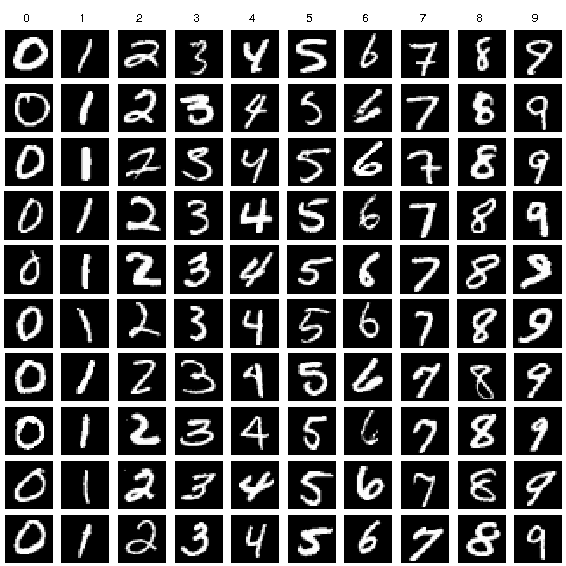

### Task description

In the terms of machine learning, the Hand-written digits recognition can be threated as a multi-class classification problem. This is very important knowledge to structure our model in the correct way (Especially the output-layer, including the number of neurons and activations function and the overall loss function and classification metrics)

### 0. Import libraries

Import the all necessary libraries, you can get inspired by the previous exercises. You can improst the libraries gradually, when do you progressing with the task

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, BatchNormalization
from keras.models import Sequential

font = {'weight': 'bold', 'size': 12}
matplotlib.rc('font', **font)

2026-03-25 12:20:14.904274: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-25 12:20:14.961667: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-25 12:20:16.553762: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


### 1. Dataset

#### 1.1 Load Dataset

You can load the dataset using the following code

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

#### 1.2 Dataset examination

Using the following code, display random images,

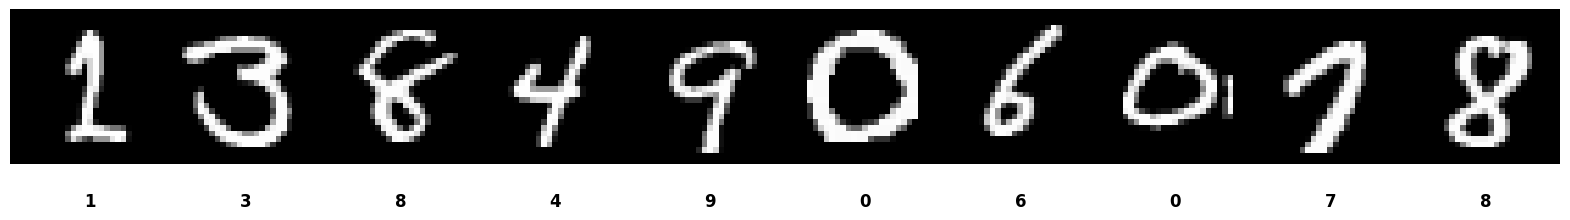

Training samples: 60000
Testing samples : 10000
Image size      : (28, 28) (grayscale)
Number of classes: 10


In [3]:
def show_digit_samples(image_set: np.ndarray, label_set: np.ndarray, n_examples: int = 10) -> None:
    random_positions = np.random.choice(np.arange(image_set.shape[0]), size=n_examples, replace=False)
    sampled_images = image_set[random_positions]
    sampled_labels = label_set[random_positions]

    montage = np.concatenate(sampled_images, axis=1)

    plt.figure(figsize=(20, 5))
    plt.imshow(montage, cmap="gray")
    for sample_idx, digit_value in enumerate(sampled_labels):
        plt.text(14 + 28 * sample_idx, 28 * (5 / 4), str(digit_value), ha="center")
    plt.axis("off")
    plt.show()

show_digit_samples(X_train, y_train)
print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])
print("Image size      :", X_train.shape[1:], "(grayscale)")
print("Number of classes:", len(np.unique(y_train)))

Examine the dataset. Answer for yourself the following questions:

- What kind of data occurs in our dataset?
- How many data samples do we have in train and test datasets?
- How many colour channels does the input variable have?
- What is the size of the input images?
- What is the necessary preprocessing of the input data X?
- How many classes do we have in target varoable?
- What is the necessary preprocessing of target variable y?

#### 1.3 Dataset preprocessing

Perform the necessary data preprocessing. The best way to preprocess the data would be one hot encoding for the target variable and normalization for the input variable (using min-max or z-score normalization)

In [4]:
from keras.utils import to_categorical


# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# One-hot encoding

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (60000, 28, 28, 1)
X_test shape : (10000, 28, 28, 1)
y_train shape: (60000, 10)
y_test shape : (10000, 10)


### 2. Build the model

In this section, your task will be to define the model architecture. The intial structure can be defined as follows:

Input_layer -> Convolutional_layer(kernel_size=(3,3), no_channels=32) -> Maxpooling_layer(kernel_size=(2, 2)) -> Flatten_layer -> Dense_layer (num_classes)
    
    


#### 2.1 Define the model structure

In [5]:
model = Sequential()

model.add(Input(shape=(28, 28, 1)))

# Block 1
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# Flatten
model.add(Flatten())

# Dense layers
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

# Output
model.add(Dense(10, activation='softmax'))

2026-03-25 12:20:18.086430: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


#### 2.2 Compile the model

Build the model, use the relevant metrics, optimizer and loss function. While choosing the metrics and loss function, consider fact that we are are trying to solve the multiclass classification problem 

In [6]:
from keras.optimizers import Adam

learning_rate = 0.001

model.compile(
    optimizer=Adam(learning_rate=learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       409,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 463,242 (1.77 MB)

 Trainable params: 463,050 (1.77 MB)

 Non-trainable params: 192 (768.00 B)

### 3. Training stage

#### 3.1 Model training

train your model, define the relevant hyperparameters (no. epochs, batch_size), use 20p of the training data for validation

In [7]:
num_epochs = 10
train_batch_size = 64

training_log = model.fit(
    X_train,
    y_train,
    epochs=num_epochs,
    batch_size=train_batch_size,
    validation_split=0.20,
    shuffle=True,
    verbose=1
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.9319 - loss: 0.2316 - val_accuracy: 0.9787 - val_loss: 0.0758
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.9754 - loss: 0.0883 - val_accuracy: 0.9847 - val_loss: 0.0567
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.9819 - loss: 0.0638 - val_accuracy: 0.9902 - val_loss: 0.0389
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9851 - loss: 0.0506 - val_accuracy: 0.9898 - val_loss: 0.0405
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9871 - loss: 0.0468 - val_accuracy: 0.9904 - val_loss: 0.0391
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.9892 - loss: 0.0376 - val_accuracy: 0.9882 - val_loss: 0.0515
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.9901 - loss: 0.0343 - val_accuracy: 0.9899 - val_loss: 0.0379
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9907 - loss: 0.0323 - 

#### 3.1 Model Evaluation on validation data

Plot the development of the training and validation loss, and training and validation metrics.

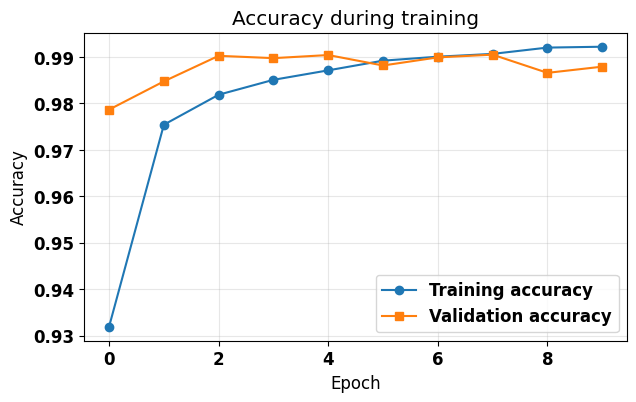

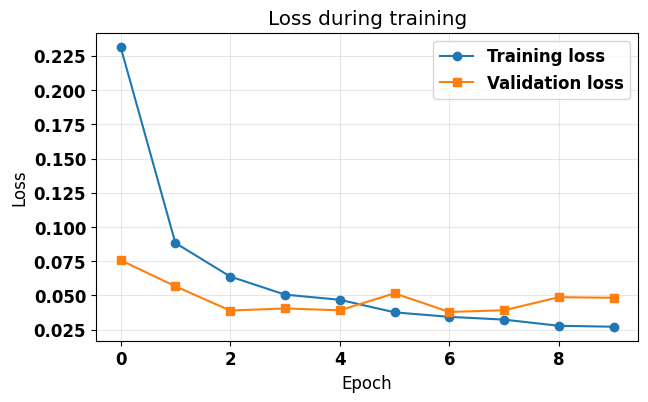

In [10]:
metric_name = "accuracy"
val_metric_name = "val_accuracy"

plt.figure(figsize=(7, 4))
plt.plot(training_log.history[metric_name], marker="o", label="Training accuracy")
plt.plot(training_log.history[val_metric_name], marker="s", label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy during training")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(training_log.history["loss"], marker="o", label="Training loss")
plt.plot(training_log.history["val_loss"], marker="s", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss during training")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 4. Model evaluation

Evaluate the model on the testing dataset using the relevant metrics. Use the confusion metrics as the one of the metrics.

Final Test Loss : 0.0364
Final Test Accuracy : 0.9902


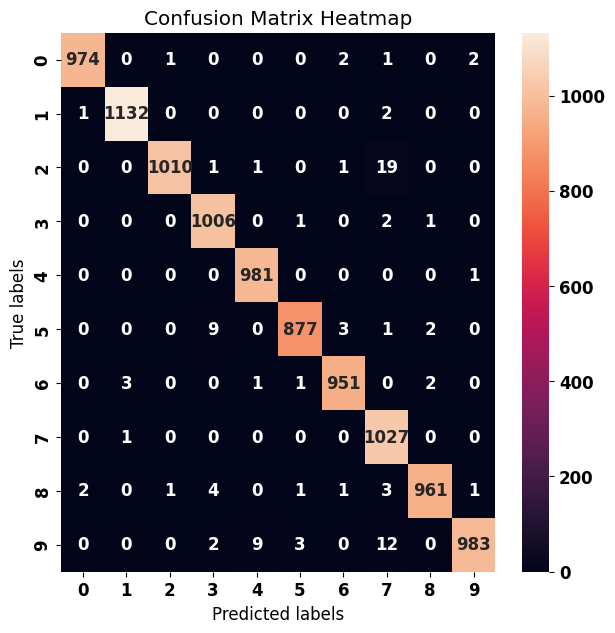

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       980
           1       1.00      1.00      1.00      1135
           2       1.00      0.98      0.99      1032
           3       0.98      1.00      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.98      0.99       892
           6       0.99      0.99      0.99       958
           7       0.96      1.00      0.98      1028
           8       0.99      0.99      0.99       974
           9       1.00      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Evaluation
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("Final Test Loss :", round(test_loss, 4))
print("Final Test Accuracy :", round(test_acc, 4))

# Predictions
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,7))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

# Classification report
report = classification_report(y_true, y_pred)
print("Classification Report:\n")
print(report)

### 5. Hyperparameter tunning and regularization techniques

When your code is ready and fully functional, try several changes in the hyperparameters and see how they influence the testing metrics. Try changes in the network structure. You can also try adding regularization techniques such as L1, L2, and Dropout. Based on the development of training and validation loss, try to identify overfitting and avoid it

In [13]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Model definition
model_v2 = Sequential()

model_v2.add(Input(shape=(28, 28, 1)))

# Block 1
model_v2.add(Conv2D(32, (3,3), activation='relu', padding='same', kernel_regularizer=l2(0.0001)))
model_v2.add(BatchNormalization())
model_v2.add(MaxPooling2D(2,2))

# Block 2
model_v2.add(Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=l2(0.0001)))
model_v2.add(BatchNormalization())
model_v2.add(MaxPooling2D(2,2))

# Classifier
model_v2.add(Flatten())
model_v2.add(Dense(128, activation='relu', kernel_regularizer=l2(0.0001)))
model_v2.add(Dropout(0.25))
model_v2.add(Dense(10, activation='softmax'))

# Compilation
model_v2.compile(
    optimizer=Adam(learning_rate=0.0007),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# Training
history_v2 = model_v2.fit(
    X_train,
    y_train,
    epochs=12,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Evaluation
loss_v2, acc_v2 = model_v2.evaluate(X_test, y_test, verbose=0)

print("Improved model results:")
print("Loss :", round(loss_v2, 4))
print("Accuracy :", round(acc_v2, 4))


Epoch 1/12
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.9491 - loss: 0.1968 - val_accuracy: 0.9827 - val_loss: 0.0938
Epoch 2/12
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9800 - loss: 0.1011 - val_accuracy: 0.9873 - val_loss: 0.0792
Epoch 3/12
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9854 - loss: 0.0855 - val_accuracy: 0.9868 - val_loss: 0.0867
Epoch 4/12
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9871 - loss: 0.0806 - val_accuracy: 0.9887 - val_loss: 0.0830
Improved model results:
Loss : 0.0741
Accuracy : 0.9884
